# **Projet AARN : Deep Learning for Crop Classification Using Multi-Source Satellite Data**
# **Part 3: Model Design and Improvement - InceptionTime**
----------------------------------------------

## **Project Content**
1. Literature Review: review additional relevant papers on crop mapping or satellite time-series modeling and identify limitations of the reproduced model.
2. Proposed Model: propose an improved architecture, train it on the prepared dataset, evaluate it with the same metrics used in Part 1, and compare it with the covariate-enhanced model from Part 2.

----------------------------------------------
**Prepared by DJEFFAL Khaled Faiz**

How would MCTnet, a model that's a hybrid between CNN and transformers, compare with a CNN-only model?
This is my main interest of the following code, it implement InceptionTime which is a CNN model based on Inception that works for timeseries data.

In [1]:
import os
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
data_path = os.path.join("drive", "MyDrive", "AARN_Projet", "AdditionalData")
model_path = os.path.join("drive", "MyDrive", "AARN_Projet", "Models")
os.makedirs(model_path, exist_ok=True)


Mounted at /content/drive


# **Data Loading**
Same exact data as MCTNet model in part 1

In [2]:
import os
import pandas as pd

cal1 = pd.read_csv(os.path.join(data_path, "california/region1/crops_CDL_CaliforniaRegion1.csv"))
ark1 = pd.read_csv(os.path.join(data_path, "arkansas/region1/crops_CDL_ArkansasRegion1.csv"))
ark2 = pd.read_csv(os.path.join(data_path, "arkansas/region2/crops_CDL_ArkansasRegion2.csv"))
cal2 = pd.read_csv(os.path.join(data_path, "california/region2/crops_CDL_CaliforniaRegion2.csv"))

# removes gee's .geo column
def clean(df):
    return df.drop(columns=['.geo', 'system:index'], errors='ignore')

cal1 = clean(cal1)
ark1 = clean(ark1)
ark2 = clean(ark2)
cal2 = clean(cal2)

# region columns
cal1['region'] = 'california1'
cal2['region'] = 'california2'
ark1['region'] = 'arkansas1'
ark2['region'] = 'arkansas2'
dataset = pd.concat([cal1, ark1, ark2, cal2], ignore_index=True)

print(dataset.shape)
dataset.head()

(16381, 362)


,0_B11,0_B12,0_B2,0_B3,0_B4,0_B5,0_B6,0_B7,0_B8,0_B8A,...,9_B2,9_B3,9_B4,9_B5,9_B6,9_B7,9_B8,9_B8A,cropland,region
0,0.2174,0.1754,0.0446,0.0526,0.0712,0.0861,0.1122,0.1247,0.1502,0.1514,...,0.04830,0.07935,0.09520,0.12490,0.20420,0.22890,0.2480,0.24875,72,california1
1,0.2371,0.2155,0.0426,0.0512,0.0696,0.0866,0.0913,0.1085,0.1202,0.1306,...,0.06450,0.08805,0.10680,0.14150,0.20065,0.21780,0.2378,0.24690,69,california1
2,0.2176,0.1655,0.0582,0.0700,0.0920,0.1263,0.1517,0.1721,0.1824,0.2025,...,0.05375,0.07860,0.09935,0.13720,0.18125,0.19655,0.2122,0.21885,71,california1
3,0.2439,0.2090,0.0522,0.0637,0.0780,0.1377,0.1420,0.1610,0.1570,0.1704,...,0.04855,0.07910,0.08895,0.16230,0.22490,0.25080,0.2700,0.26330,121,california1
4,0.1817,0.1397,0.0391,0.0526,0.0679,0.0957,0.1224,0.1407,0.1622,0.1659,...,0.04570,0.07110,0.08980,0.12605,0.17075,0.18405,0.2061,0.20685,71,california1


In [3]:
# class names
CLASS_NAMES = {
    1: "Corn",
    2: "Cotton",
    3: "Rice",
    5: "Soybeans",
    61: "Fallow/Idle Cropland",
    66: "Cherries",
    69: "Grapes",
    71: "Other Tree Crops",
    72: "Citrus",
    74: "Alfalfa",
    75: "Almonds",
    121: "Developed/Open Space",
    204: "Pistachios",
    999: "Others",
}

# merge small classes into others
threshold = 0.02 * len(dataset)
class_counts = dataset['cropland'].value_counts()
small_classes = class_counts[class_counts < threshold].index

dataset['cropland'] = dataset['cropland'].apply(
    lambda x: 999 if x in small_classes else x
)

# Match cdl's codes with them class names
named_counts = dataset['cropland'].value_counts().rename(index=CLASS_NAMES)
print(named_counts)

# supprimer 5000 samples de la classe 3 pour l'equilibre
# merge small classes into others
threshold = 0.02 * len(dataset)
class_counts = dataset['cropland'].value_counts()

small_classes = class_counts[class_counts < threshold].index

dataset['cropland'] = dataset['cropland'].apply(
    lambda x: 999 if x in small_classes else x
)

# Match cdl's codes with them classnaems
named_counts = dataset['cropland'].value_counts().rename(index=CLASS_NAMES)
print(named_counts)


# supprimer 5000 samples de la classe 3 pour l'equilibre
class_3 = dataset[dataset['cropland'] == 3]
to_remove = class_3.sample(n=5000, random_state=42)
dataset = dataset.drop(to_remove.index)


named_counts = dataset['cropland'].value_counts().rename(index=CLASS_NAMES)
print("After removing the rice samples : ", named_counts)

cropland
Rice        8667
Soybeans    2915
Corn        2403
Others      1078
Cotton       712
Grapes       606
Name: count, dtype: int64
cropland
Rice        8667
Soybeans    2915
Corn        2403
Others      1078
Cotton       712
Grapes       606
Name: count, dtype: int64
After removing the rice samples :  cropland
Rice        3667
Soybeans    2915
Corn        2403
Others      1078
Cotton       712
Grapes       606
Name: count, dtype: int64


# **X and Y**
- X = données (features)
- y = labels (types de cultures)

In [4]:
X = dataset.drop(columns=['cropland', 'region']).values
y = dataset['cropland'].values

print(X.shape)

# make it shape 36, 10 (time series)
X = X.reshape(len(X), 36, 10)
print("X shape:", X.shape)

# Transforms the classes into vector
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(label_encoder.classes_)
print("Classes:", num_classes)

(11381, 360)
X shape: (11381, 36, 10)
Classes: 6


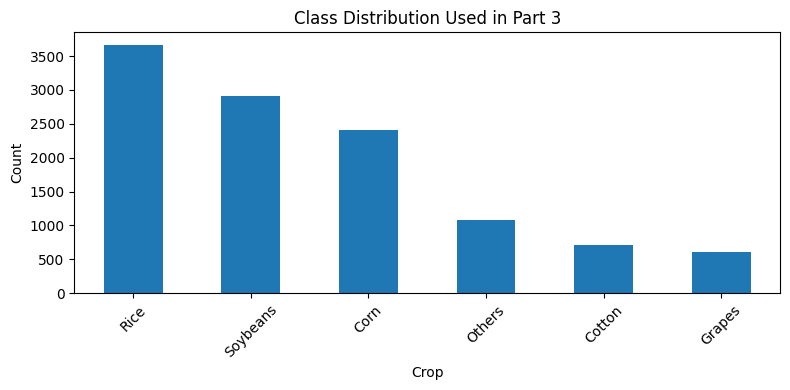

In [5]:
import matplotlib.pyplot as plt
named_counts = dataset["cropland"].value_counts().rename(index=CLASS_NAMES)

plt.figure(figsize=(8, 4))
named_counts.plot(kind="bar", color="#1f77b4")
plt.title("Class Distribution Used in Part 3")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# **Train Test Split**
below code splits data in a roughly similar way to teh article

In [6]:
from sklearn.model_selection import train_test_split

def split_data(df, n_train=240, n_val=60):
    train_list, val_list, test_list = [], [], []
    for cls, group in df.groupby('cropland'):
        group = group.sample(frac=1, random_state=42).reset_index(drop=True)
        train_list.append(group.iloc[:n_train])
        val_list.append(group.iloc[n_train:n_train + n_val])
        test_list.append(group.iloc[n_train + n_val:])
    return pd.concat(train_list), pd.concat(val_list), pd.concat(test_list)

ark = dataset[dataset['region'].isin(['arkansas1', 'arkansas2'])]
cal = dataset[dataset['region'].isin(['california1', 'california2'])]

ark_train, ark_val, ark_test = split_data(ark)
cal_train, cal_val, cal_test = split_data(cal)

train_df = pd.concat([ark_train, cal_train])
val_df   = pd.concat([ark_val,   cal_val])
test_df  = pd.concat([ark_test,  cal_test])

feature_cols = [c for c in dataset.columns if '_B' in c]

X_train = train_df[feature_cols].values.reshape(-1, 36, 10)
X_val   = val_df[feature_cols].values.reshape(-1, 36, 10)
X_test  = test_df[feature_cols].values.reshape(-1, 36, 10)

y_train = label_encoder.fit_transform(train_df['cropland'].values)
y_val   = label_encoder.transform(val_df['cropland'].values)
y_test  = label_encoder.transform(test_df['cropland'].values)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (1916, 36, 10)
Val:   (420, 36, 10)
Test:  (9045, 36, 10)


--------------------------
# **InceptionTime (CNN) Architecture**
Variant of a CNN that uses inception modules that run several 1 dimensional convolutions that are then concatenated as an output. This is very similar to InceptionV1 (google's CNN model) except it is applied for temporal datasets. It's architecture is simple and very interesting

# Ressource :
- https://arxiv.org/abs/1909.04939
- https://www.mdpi.com/2072-4292/16/23/4548

In [19]:
import keras
from keras import layers, ops

def inception_module(x, filters=32, bottleneck_size=32, kernel_sizes=(9, 19, 39)):
    # Bottleneck that reduces channels
    if x.shape[-1] > 1:
        bottleneck = layers.Conv1D(bottleneck_size, kernel_size=1, padding='same', use_bias=False)(x)
    else:
        bottleneck = x

    # parallel covnvs
    branches = []
    for k in kernel_sizes:
        branch = layers.Conv1D(filters, kernel_size=k, padding='same', use_bias=False)(bottleneck)
        branches.append(branch)

    #max pooling
    mp_branch = layers.MaxPooling1D(pool_size=3, strides=1, padding='same')(x)
    mp_branch = layers.Conv1D(filters, kernel_size=1, padding='same', use_bias=False)(mp_branch)
    branches.append(mp_branch)

    # final concatenation of all branches
    x = layers.Concatenate()(branches)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x


def build_inception_time(num_classes,seq_len=36,in_channels=10,nb_filters=32,bottleneck_size=32,depth=6,kernel_sizes=(9, 19, 39),):
    inputs = keras.Input(shape=(seq_len, in_channels))
    x = inputs
    residual = inputs

    for d in range(depth):
        x = inception_module(x, filters=nb_filters, bottleneck_size=bottleneck_size, kernel_sizes=kernel_sizes)

        # residual layer
        if (d + 1) % 3 == 0:
            shortcut = layers.Conv1D(nb_filters * 4, kernel_size=1, padding='same', use_bias=False)(residual)
            shortcut = layers.BatchNormalization()(shortcut)
            x = layers.Add()([x, shortcut])
            x = layers.Activation('relu')(x)
            residual = x
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='InceptionTime')

model = build_inception_time(num_classes=num_classes)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "InceptionTime"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 36, 32)    │        320 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 36, 10)    │          0 │ input_layer_7[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 36, 32)    │      9,216 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 36, 32)    │     19,456 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 36, 32)    │     39,936 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 36, 32)    │        320 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 36, 128)   │          0 │ conv1d_1[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 36, 128)   │        512 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 36, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 36, 32)    │      4,096 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 36, 128)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 36, 32)    │      9,216 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 36, 32)    │     19,456 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 36, 32)    │     39,936 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 36, 32)    │      4,096 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 36, 128)   │          0 │ conv1d_6[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_7[0][0],   │
│                     │                   │            │ conv1d_8[0][0],   │
│                     │                   │            │ conv1d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 128)   │        512 │ concatenate_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 36, 128)   │          0 │ batch_normalizat

 Total params: 475,782 (1.81 MB)

 Trainable params: 473,734 (1.81 MB)

 Non-trainable params: 2,048 (8.00 KB)

# **Training**


In [20]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
callbacks = [
    ModelCheckpoint('best_TSVIT.keras', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-6,verbose=1),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 169ms/step - accuracy: 0.8486 - loss: 0.4180 - val_accuracy: 0.2643 - val_loss: 1.8537 - learning_rate: 0.0010
Epoch 2/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9322 - loss: 0.1871 - val_accuracy: 0.1690 - val_loss: 2.3713 - learning_rate: 0.0010
Epoch 3/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9504 - loss: 0.1409 - val_accuracy: 0.3452 - val_loss: 2.3013 - learning_rate: 0.0010
Epoch 4/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9541 - loss: 0.1269 - val_accuracy: 0.3262 - val_loss: 2.4229 - learning_rate: 0.0010
Epoch 5/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9572 - loss: 0.1235 - val_accuracy: 0.4167 - val_loss: 1.7652 - learning_rate: 0.0010
Epoch 6/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9619 - loss: 0.1058 - val_accuracy: 0.5571 - val_loss: 1.2151 - learning_rate: 0.0010
Epoch 7/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9656 - loss: 0.0897 - val_ac

# **Training Curves**


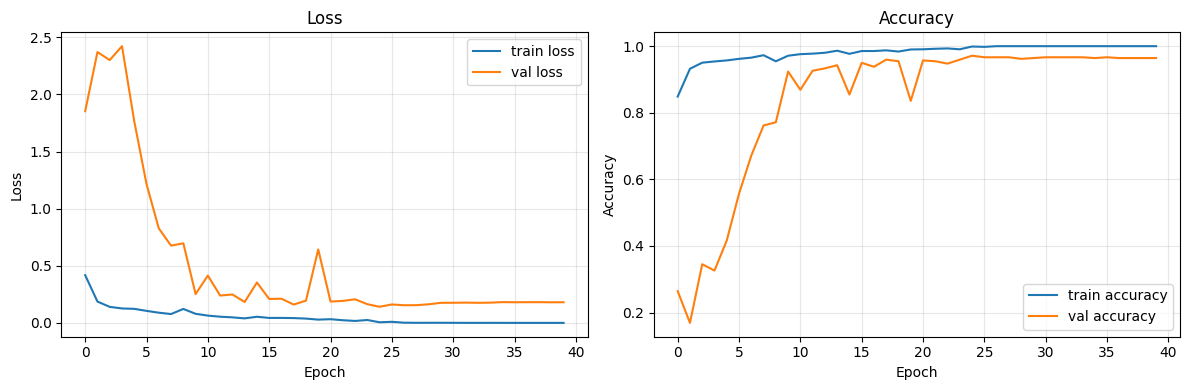

In [21]:
# Learning plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"], label="train accuracy")
axes[1].plot(history.history["val_accuracy"], label="val accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# **Evaluation**

In [22]:
from sklearn.metrics import cohen_kappa_score, f1_score
import numpy as np
# prediction
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

oa    = (y_pred == y_test).mean()
kappa = cohen_kappa_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred, average='macro')

print(f"OA: {oa:.3f} | Kappa: {kappa:.3f} | F1: {f1:.3f}")

283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
OA: 0.983 | Kappa: 0.977 | F1: 0.960


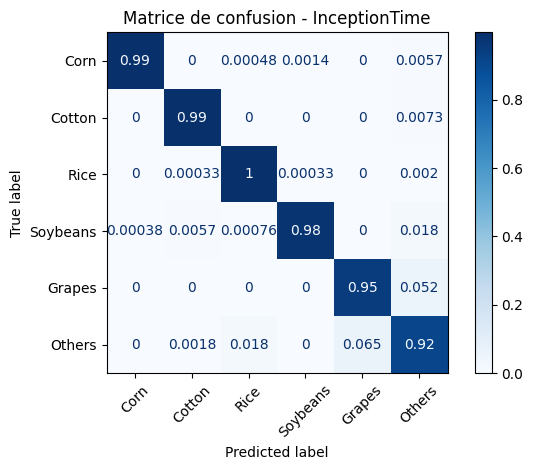


Classification Report - InceptionTime :

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      2103
           1       0.96      0.99      0.98       412
           2       1.00      1.00      1.00      3067
           3       1.00      0.98      0.99      2615
           4       0.89      0.95      0.92       306
           5       0.86      0.92      0.88       542

    accuracy                           0.98      9045
   macro avg       0.95      0.97      0.96      9045
weighted avg       0.98      0.98      0.98      9045


OA: 0.983 | Kappa: 0.977 | F1: 0.960


In [24]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
class_names = [CLASS_NAMES[code] for code in label_encoder.classes_]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matrice de confusion - InceptionTime")
plt.tight_layout()
plt.show()

# Precision / Recall / F1
print("\nClassification Report - InceptionTime :\n")
print(classification_report(y_test, y_pred))

# OA / Kappa / F1
from sklearn.metrics import cohen_kappa_score, f1_score
oa    = np.mean(y_pred == y_test)
kappa = cohen_kappa_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred, average='macro')
print(f"\nOA: {oa:.3f} | Kappa: {kappa:.3f} | F1: {f1:.3f}")

In [25]:
# Save 2nd model
model.save(os.path.join("drive", "MyDrive", "AARN_Projet", "Models", 'InceptionTime.keras'))


# **Comparaison**
Comparison between part 3 model + part 2 and 1 models


In [2]:
import pandas as pd
comparison_results = pd.DataFrame([
    {"Model": "MCTNet (baseline)", "OA": 0.972, "Kappa": 0.964, "Macro F1": 0.948},
    {"Model": "MCTNet (all covariates)", "OA": 0.983, "Kappa": 0.978, "Macro F1": 0.973},
    {"Model": "InceptionTime", "OA": 0.983, "Kappa": 0.977, "Macro F1": 0.960},
    {"Model": "IncepTAE-CovLF", "OA": 0.982, "Kappa": 0.977, "Macro F1": 0.966},
    {"Model": "HybridCropNet", "OA": 0.978, "Kappa": 0.971, "Macro F1": 0.954}
])
comparison_results


,Model,OA,Kappa,Macro F1
0,MCTNet (baseline),0.972,0.964,0.948
1,MCTNet (all covariates),0.983,0.978,0.973
2,InceptionTime,0.983,0.977,0.960
3,IncepTAE-CovLF,0.982,0.977,0.966
4,HybridCropNet,0.978,0.971,0.954


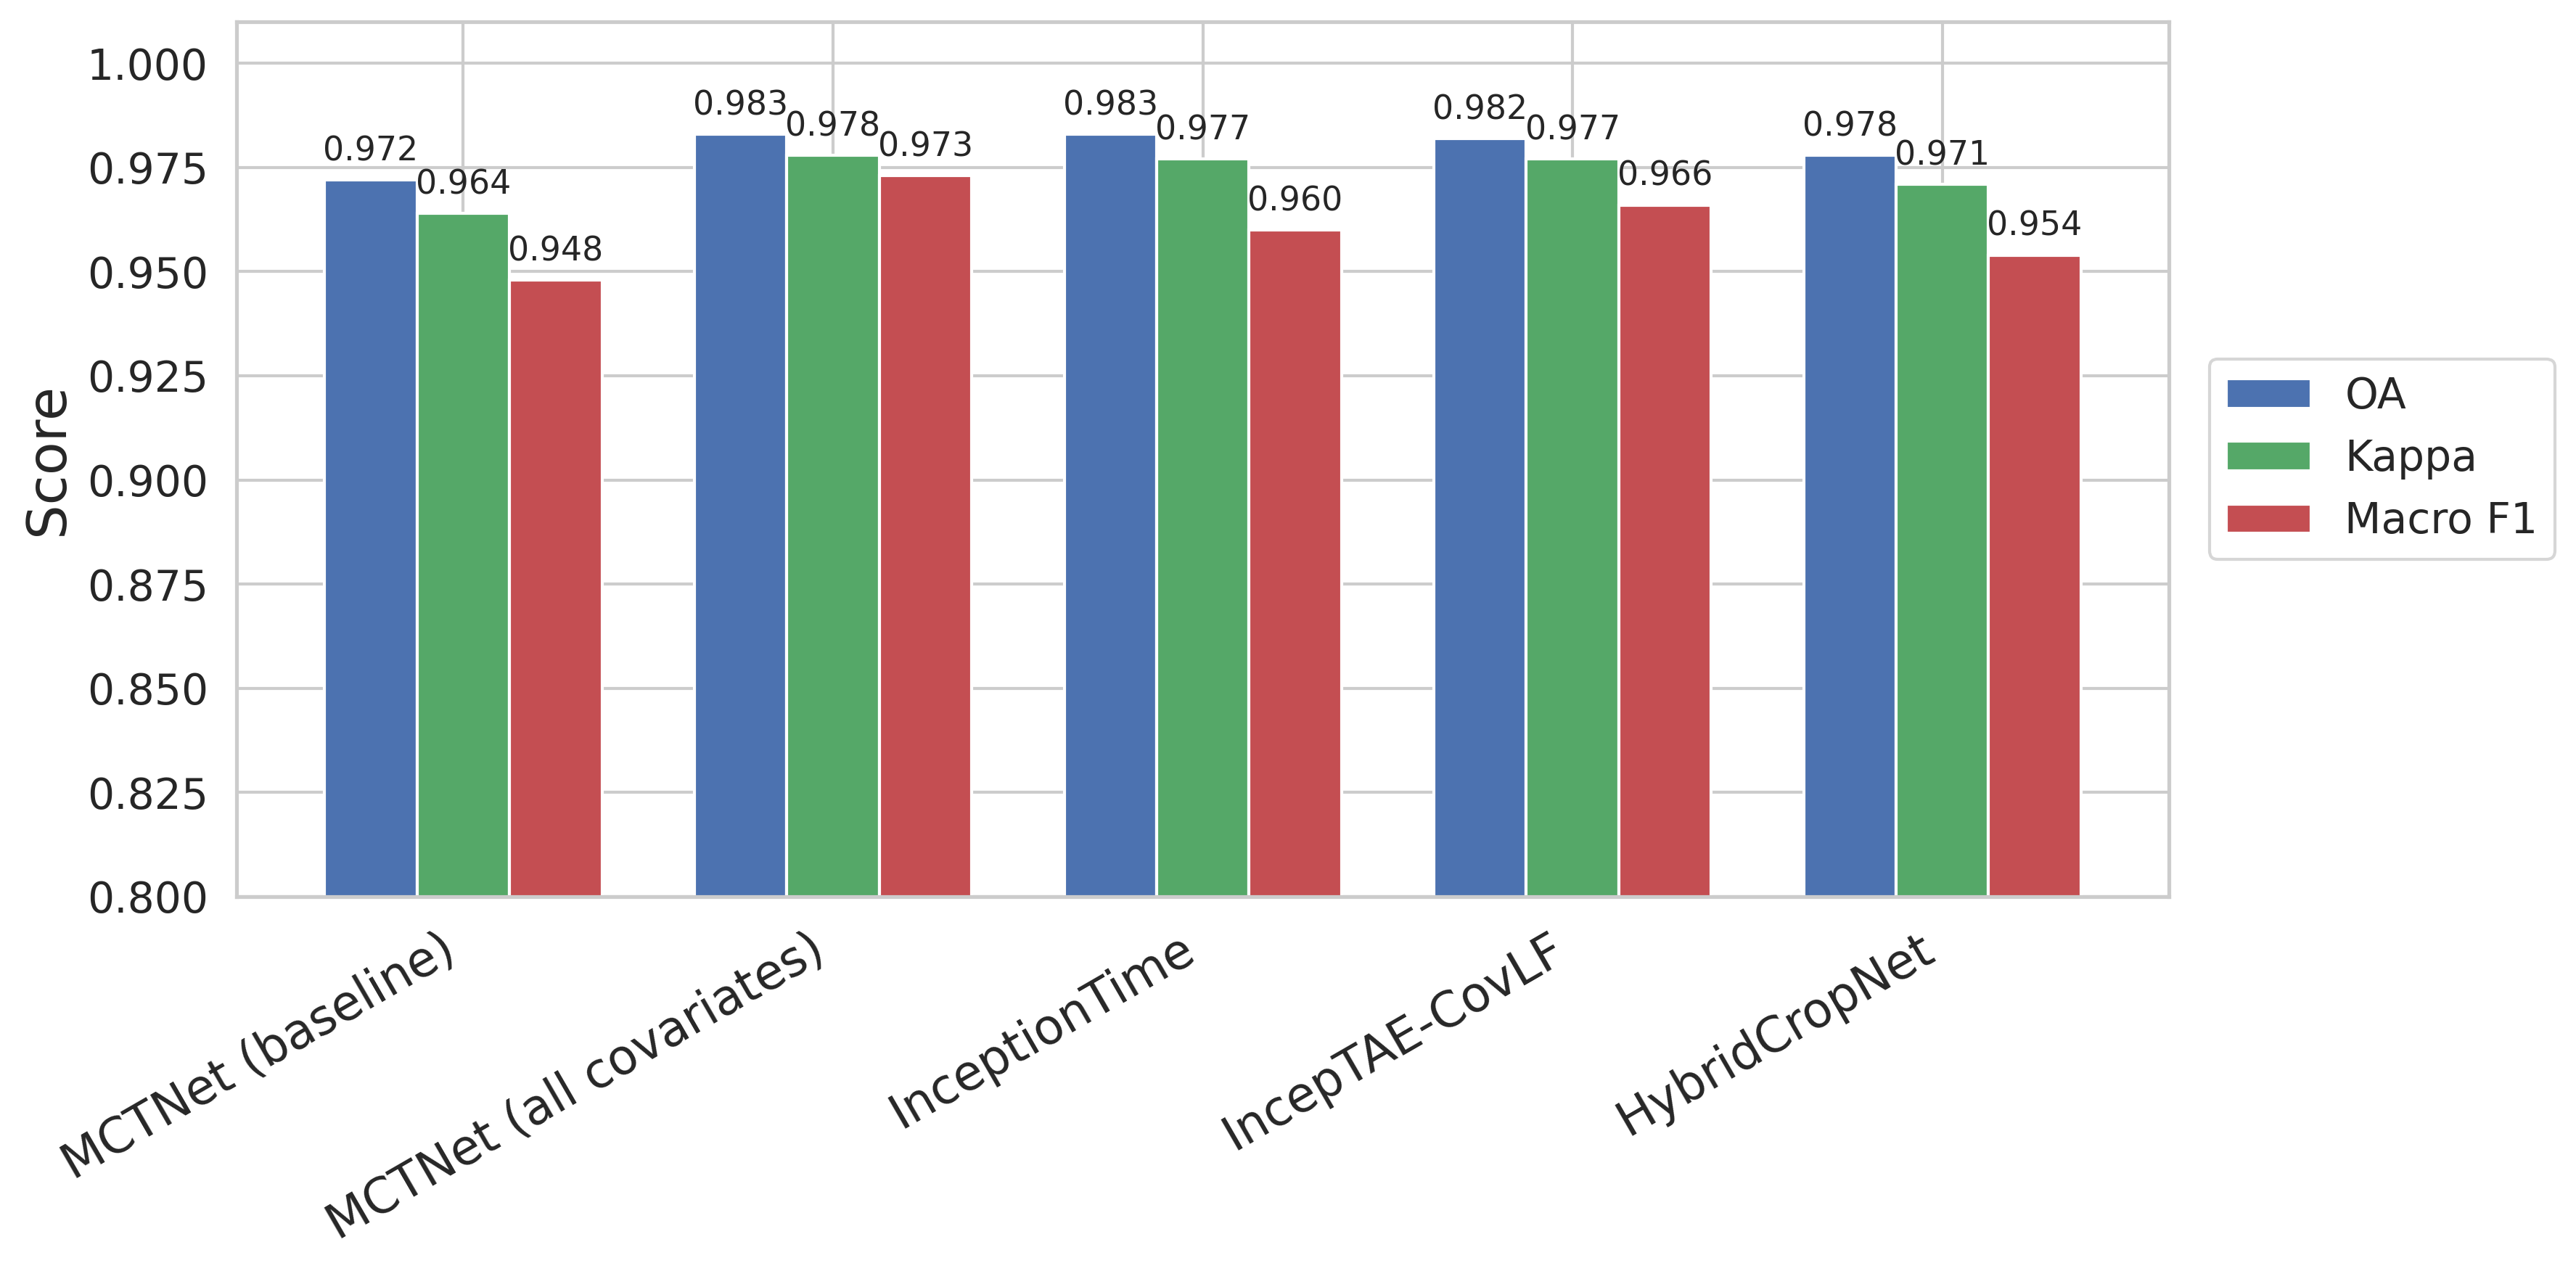

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plot_df = comparison_results.dropna(subset=["OA", "Kappa", "Macro F1"]).copy()
models = plot_df["Model"].tolist()
oa    = plot_df["OA"].tolist()
kappa = plot_df["Kappa"].tolist()
f1    = plot_df["Macro F1"].tolist()

x = np.arange(len(models))
width = 0.25

sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

bars1 = ax.bar(x - width, oa,    width, label="OA",       color="#4C72B0")
bars2 = ax.bar(x,         kappa, width, label="Kappa",    color="#55A868")
bars3 = ax.bar(x + width, f1,    width, label="Macro F1", color="#C44E52")

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.annotate(
            f"{bar.get_height():.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4), textcoords="offset points",
            ha="center", va="bottom", fontsize=11,
        )

ax.set_ylim(0.80, 1.01)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha="right", fontsize=16)
ax.set_ylabel("Score", fontsize=18)
ax.legend(fontsize=14, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True)
ax.tick_params(axis="y", labelsize=14)

plt.tight_layout()
plt.savefig("part3_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()